# Tariff and controller experiments

A reusable local controller with scheduled storage, reserves, persistent staggering,
export caps, and bounded voltage-trend feedback. The controller observes no price.
Each tariff selects a policy using mean household settlement on training weather.

Run the experiment from the repository root:
```sh
.venv/bin/python -m sandbox.experiments --output results/controller_framework
```
This notebook reads the saved run; reopening it does not silently repeat training.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "sandbox").exists() else Path.cwd().parent
RESULTS = ROOT / "results" / "controller_framework"
manifest = json.loads((RESULTS / "manifest.json").read_text())
selection = json.loads((RESULTS / "selection.json").read_text())
metrics = pd.read_csv(RESULTS / "metrics.csv")
tuning = pd.read_csv(RESULTS / "tuning.csv")
households = pd.read_csv(RESULTS / "household_settlements.csv")
print("Weather splits:", manifest["seeds"], "roots:", manifest["roots"])
print("Finalist:", selection)


Weather splits: {'train': 4, 'validation': 8, 'test': 20} roots: {'train': 11003, 'validation': 22007, 'test': 33013}
Finalist: {'finalist': 'export_30kw_0.3', 'eligible': [], 'accepted': False, 'rule': 'Lowest validation export peak among candidates passing declared screens; if none pass, lowest peak is tested as a diagnostic, not a recommendation.'}


## Independent test results
Positive settlement means a household receives money. Lower cost per actual load kWh
is better. Official fields named cost_per_kwh use grid imports as their
denominator; these can diverge near zero imports. Use the added cost_per_load_kwh
fields for incidence comparisons. A lower peak alone does not establish a better tariff; inspect
curtailment, synchrony, and incidence alongside it.


,transformer_export_peak_kw,transformer_draw_peak_kw,max_ramp_kw,coincidence_factor,curtailed_share,community_settlement_chf,tenant_cost_per_load_kwh_chf,valid_share
run,,,,,,,,
fair_leg/default_base,65.3049,7.8951,15.2799,0.7683,0.0150,294.2796,0.2231,1.0
fair_leg/tuned_family,65.7581,8.8408,9.8071,0.7809,0.0029,305.1945,0.2235,1.0
tariff/fixed_base,65.3049,7.8951,15.2799,0.7683,0.0150,294.2796,-0.3614,1.0
tariff/tuned_base,39.0396,8.2294,24.6133,0.8513,0.1911,187.0384,0.1443,1.0
tariff/tuned_family,37.8781,8.0283,7.1382,0.8615,0.1868,191.9608,0.1518,1.0
tariff/voltage_family,37.3012,8.1526,6.8496,0.8551,0.1923,188.6821,0.1591,1.0
tariff/voltage_off_matched,37.8781,8.0283,7.1382,0.8615,0.1868,191.9608,0.1518,1.0


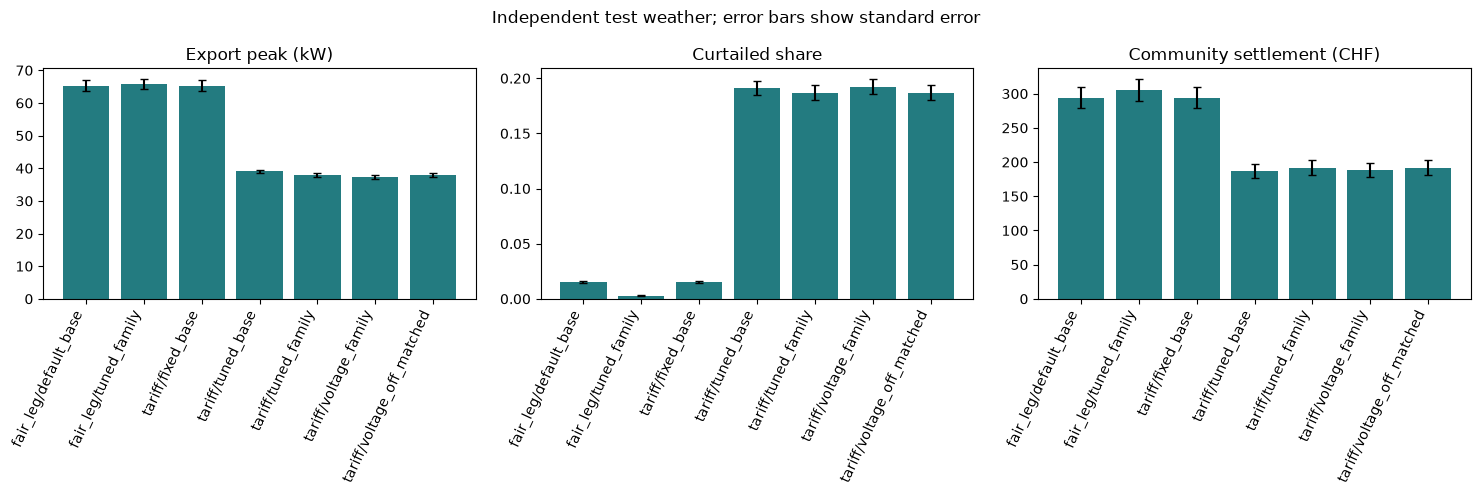

In [2]:
test = metrics.query("split == 'test'")
columns = ["transformer_export_peak_kw", "transformer_draw_peak_kw", "max_ramp_kw",
           "coincidence_factor", "curtailed_share", "community_settlement_chf",
           "tenant_cost_per_load_kwh_chf", "valid_share"]
display(test.groupby("run")[columns].mean().round(4))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, field, title in zip(axes, columns[:1] + ["curtailed_share", "community_settlement_chf"],
                           ["Export peak (kW)", "Curtailed share", "Community settlement (CHF)"]):
    means = test.groupby("run")[field].mean()
    errors = test.groupby("run")[field].sem()
    ax.bar(range(len(means)), means, yerr=errors, capsize=3, color="#237b80")
    ax.set_xticks(range(len(means)), means.index, rotation=65, ha="right")
    ax.set_title(title)
fig.suptitle("Independent test weather; error bars show standard error")
fig.tight_layout()
fig.savefig(RESULTS / "test_comparison.png", dpi=160, bbox_inches="tight")


## Tariff response and household incidence
The frozen bank is searched identically for each tariff. A gap of zero identifies
the training winner; small CHF gaps indicate uncertain private preferences.
Tenants are included below even though the standard tuner excludes them.


In [3]:
display(tuning.query("controller == 'family'").sort_values(["tariff", "gap_chf"])
        .groupby("tariff").head(3))
display(households.query("split == 'test'")
        .groupby(["run", "household"]).settlement_chf.mean().unstack().round(3))
paired = json.loads((RESULTS / "paired_deltas.json").read_text())
display(pd.DataFrame(paired).T.round(5))

incidence = households.query("split == 'test'").groupby(["run", "household"])[["settlement_chf", "load_kwh"]].sum()
incidence["cost_per_actual_load_kwh_chf"] = -incidence.settlement_chf / incidence.load_kwh
display(incidence.cost_per_actual_load_kwh_chf.unstack().round(4))


,tariff,controller,candidate,mean_return_chf,gap_chf,selected
43,export_30kw_0.05,family,5,31.105652,0.000000,True
44,export_30kw_0.05,family,6,31.103203,0.002449,False
41,export_30kw_0.05,family,3,31.075897,0.029755,False
79,export_30kw_0.15,family,3,25.615253,0.000000,True
81,export_30kw_0.15,family,5,25.605083,0.010170,False
89,export_30kw_0.15,family,13,25.556660,0.058594,False
125,export_30kw_0.3,family,11,22.030300,0.000000,True
131,export_30kw_0.3,family,17,21.866922,0.163378,False
135,export_30kw_0.3,family,21,20.796440,1.233860,False
155,export_45kw_0.05,family,3,32.988979,0.000000,True


household,large_flex,pv_battery,pv_only,tenant
run,,,,
fair_leg/default_base,30.365,35.507,22.418,-14.176
fair_leg/tuned_family,31.775,36.496,22.153,-14.198
tariff/fixed_base,8.099,15.202,16.852,22.828
tariff/tuned_base,17.937,23.446,14.993,-9.228
tariff/tuned_family,19.102,23.969,14.973,-9.701
tariff/voltage_family,19.107,23.848,15.067,-10.162
tariff/voltage_off_matched,19.102,23.969,14.973,-9.701


,mean_delta,std_delta,se_delta
transformer_draw_peak_kw,-8.124400e-01,8.275100e-01,1.850400e-01
transformer_export_peak_kw,-2.787998e+01,4.890850e+00,1.093630e+00
reverse_flow_share,1.190000e-03,1.240000e-03,2.800000e-04
losses_share,-3.266000e-02,6.250000e-03,1.400000e-03
voltage_p99_pu,-3.059000e-02,1.047000e-02,2.340000e-03
over_voltage_share,-5.464000e-02,2.198000e-02,4.910000e-03
coincidence_factor,8.060000e-02,3.545000e-02,7.930000e-03
peak_to_average,-9.177800e-01,2.084600e-01,4.661000e-02
max_ramp_kw,-2.668880e+00,2.732120e+00,6.109200e-01
flex_synchrony,-1.720700e-01,1.991000e-02,4.450000e-03


household,large_flex,pv_battery,pv_only,tenant
run,,,,
fair_leg/default_base,-0.1479,-0.4197,-0.2634,0.2231
fair_leg/tuned_family,-0.1548,-0.4314,-0.2602,0.2235
tariff/fixed_base,-0.0395,-0.1797,-0.1980,-0.3593
tariff/tuned_base,-0.0874,-0.2771,-0.1761,0.1452
tariff/tuned_family,-0.0931,-0.2833,-0.1759,0.1527
tariff/voltage_family,-0.0931,-0.2819,-0.1770,0.1599
tariff/voltage_off_matched,-0.0931,-0.2833,-0.1759,0.1527


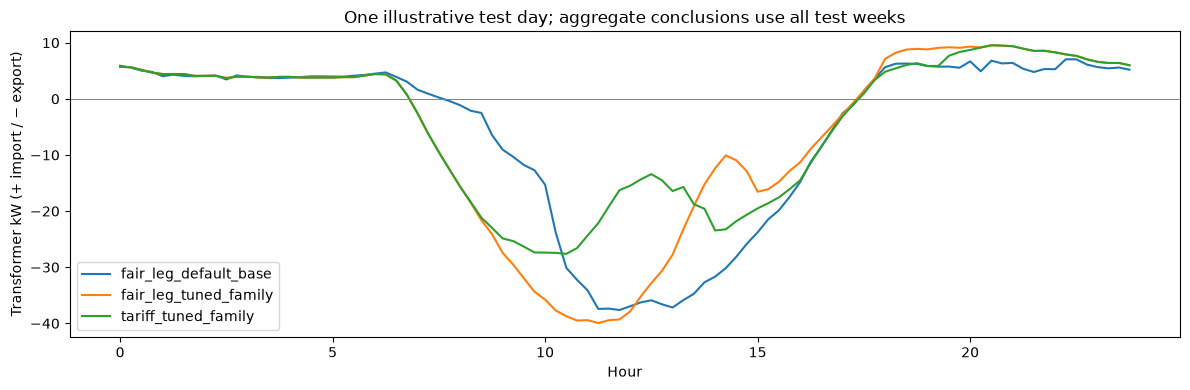

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for label in ["fair_leg_default_base", "fair_leg_tuned_family", "tariff_tuned_family"]:
    frame = pd.read_csv(RESULTS / f"{label}_feeder_trace.csv")
    day = frame.query("day == 2").sort_values("hour")
    ax.plot(day.hour, day.transformer_kw, label=label)
ax.axhline(0, color="grey", lw=0.7)
ax.set(xlabel="Hour", ylabel="Transformer kW (+ import / − export)",
       title="One illustrative test day; aggregate conclusions use all test weeks")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "feeder_day.png", dpi=160)


## Interpretation limits

The response is a shared-policy approximation, not a market equilibrium.
Use `sandbox.response_audit.audit_deviations` to check unilateral policy changes.
The official `score()` report remains available through `sandbox.my_idea` and
uses its original tuning and seed conventions. This experiment's fair-LEG
family comparator is explicitly tuned and uses separate weather roots.

The bank is deliberately finite. Expand it after diagnosing a missing behaviour,
then rerun every tariff using the same expanded bank. Battery wear is not included
in the current household settlement objective.
